In [ ]:
# %pip install pandas
# %pip install kagglehub

In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory


# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md
# import kagglehub

# **Data Exploration**

In [5]:

# # For Kaggle Notebook
# base = '/kaggle/input/competitions/rsna-knee-abnormality-detection'

# # just the top-level contents
# print(os.listdir(base))

In [2]:
# For local runs
train = pd. read_csv("raw_data/train.csv")
train

,StudyInstanceUID,Report,ACL,MCL,Medial Meniscus,Lateral Meniscus,Medial OA,Lateral OA,PF OA,Effusion,Synovitis,Baker's,Contusion,Fracture
0,1.2.826.0.1.3680043.8.498.10004873229099053869...,Técnica: RMN de la rodilla. Resultados: Rotura...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.2.826.0.1.3680043.8.498.10004945927472656027...,[DATE]: * MR Knie Rechts 15ch AA Klinische Inl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.2.826.0.1.3680043.8.498.10009278692606631573...,Hallazgos:\nNo hay alteraciones en significati...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.2.826.0.1.3680043.8.498.10009639203170750274...,"In the medial compartment, the meniscus is no...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.2.826.0.1.3680043.8.498.10013663742400736029...,CONSTATATIONS :\n\nFractures :\nAucune.\n\nAli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,1.2.826.0.1.3680043.8.498.99880021280666757817...,Exam Type: MRI KNEE RIGHT WO CONTRAST\nExam Da...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4403,1.2.826.0.1.3680043.8.498.99881620336512626242...,[DATE]: *MR Knie Rechts 15ch AA Klinische Inli...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4404,1.2.826.0.1.3680043.8.498.99926624968240681772...,"SAĞ DİZ MRG. Tetkik protokolü: Çok düzlemli, ç...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4405,1.2.826.0.1.3680043.8.498.99939100657291954890...,"MRI of Knee with \n-Locator, SG PD FatSat, SG ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
from langdetect import detect
import langcodes

# Detect which languages the reports are originally written in
def safe_detect(text):
    if pd.isna(text): # if report content is null return None value
        return None
    try:
        return detect(text)
    except:
        return None


# Convert language ISO codes to language name 
def code_to_name(code):
    if pd.isna(code):
        return None
    try:
        return langcodes.Language.get(code).display_name()
    except:
        return code  # fallback to raw code if lookup fails

train['detected_lang'] = train['Report'].apply(safe_detect)


In [4]:
# View Language stats
train['detected_lang_name'] = train['detected_lang'].apply(code_to_name)
print(train['detected_lang_name'].value_counts())


Looking up language names now requires the `language_data` package.

Install it with:
    pip install language_data
Or as an optional feature of langcodes:
    pip install langcodes[data]


Looking up language names now requires the `language_data` package.

Install it with:
    pip install language_data
Or as an optional feature of langcodes:
    pip install langcodes[data]


Looking up language names now requires the `language_data` package.

Install it with:
    pip install language_data
Or as an optional feature of langcodes:
    pip install langcodes[data]


Looking up language names now requires the `language_data` package.

Install it with:
    pip install language_data
Or as an optional feature of langcodes:
    pip install langcodes[data]


Looking up language names now requires the `language_data` package.

Install it with:
    pip install language_data
Or as an optional feature of langcodes:
    pip install langcodes[data]


Looking up language names now requires the `langu

In [5]:
train.to_csv('raw_data/train_detected_lang.csv')

In [4]:
import pandas as pd
import numpy as np

In [6]:
train_lang = pd.read_csv('raw_data/train_detected_lang.csv')

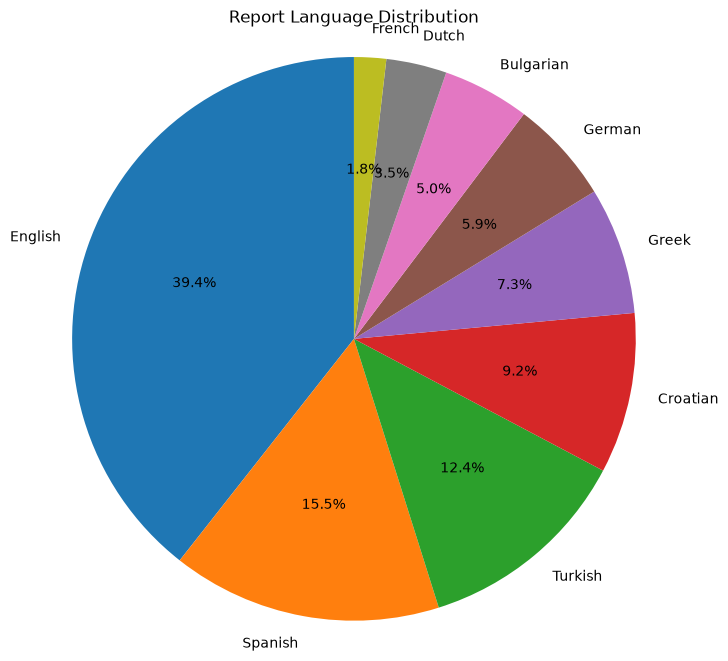

In [7]:
import matplotlib.pyplot as plt
# View language distribution
lang_counts = train_lang['detected_lang_name'].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(lang_counts, labels=lang_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Report Language Distribution')
plt.axis('equal')
plt.show()

Since 40% of our reports are in English, let us first extract keywords from these reports and validate against the gold data standard

The following is an example of how the calculation for a target variable is derived using TFIDF

In [8]:
label_cols = ["ACL", "MCL", "Medial Meniscus", "Lateral Meniscus", "Medial OA", "Lateral OA", "PF OA", "Effusion", "Synovitis", "Baker's", "Contusion", "Fracture"]

# Filter out Non NA Target variables for English reports
gold_mask = train_lang[label_cols].notna().all(axis=1)
english_gold = train_lang[gold_mask & (train_lang['detected_lang'] == 'en')]

finding = 'MCL'  # adjust to column name that is being discovered

# Filter the Positive & Negative target for a given report
positive_reports = english_gold[english_gold[finding] == 1]['Report']
negative_reports = english_gold[english_gold[finding] == 0]['Report']

print(f"Positive: {len(positive_reports)}, Negative: {len(negative_reports)}")

Positive: 5, Negative: 23


What TF-IDF actually means:

1. TF (Term Frequency) — how often a word appears in this specific report. A report that says "tear" five times scores higher on "tear" than one that says it once.
2. IDF (Inverse Document Frequency) — how rare that word is across all reports. Common words like "the," "knee," "MRI" appear in almost every report, so they get a low score (not distinctive). Rare, specific words (like "meniscal" or "Baker's cyst") get a high score, since they only show up in a subset of reports — meaning they're more likely to be meaningful signal rather than boilerplate.
3. TF-IDF = TF × IDF — combines both: a word scores high only if it appears often in this report AND is relatively rare overall. This is exactly what you want for finding distinguishing terms — words that show up a lot specifically in your positive (ACL=1) reports but rarely elsewhere.

In [9]:
import sys
print(sys.executable)

c:\Users\GargiAsthana\OneDrive - Axle\Projects\SRNA Knee Abnormality\venv\Scripts\python.exe


In [10]:
from sklearn.feature_extraction.text import TfidfVectorizer

# combine both groups, label which is which
all_reports = pd.concat([positive_reports, negative_reports])
labels = [1]*len(positive_reports) + [0]*len(negative_reports)

vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),      # look at 1-word, 2-word, and 3-word phrases
    stop_words='english',
    max_features=500
)
tfidf_matrix = vectorizer.fit_transform(all_reports)
feature_names = vectorizer.get_feature_names_out()

# average TF-IDF score per term, split by class
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['label'] = labels


positive_avg = tfidf_df[tfidf_df['label']==1].drop('label', axis=1).mean()
negative_avg = tfidf_df[tfidf_df['label']==0].drop('label', axis=1).mean()

# terms that are notably higher in positive than negative
diff = (positive_avg - negative_avg).sort_values(ascending=False)
print(diff.head(20))  # top 20 terms associated with ACL tear

anteromedial               0.073775
aspect                     0.071625
suspect                    0.070661
proximal                   0.068694
grade                      0.056655
injury                     0.053688
insertion                  0.049248
grade partial              0.048533
bony                       0.046288
partial tear               0.046098
sprain                     0.045909
fracture                   0.045497
grade partial tear         0.045263
small                      0.044881
avulsion                   0.043453
grade injury               0.038699
posterior aspect           0.038389
osteochondral impaction    0.037671
impaction                  0.037671
complete                   0.037141
dtype: float64


In [11]:
from sklearn.feature_extraction.text import TfidfTransformer

def get_top_terms(finding, n_top=20):
    positive_reports = english_gold[english_gold[finding] == 1]['Report']
    negative_reports = english_gold[english_gold[finding] == 0]['Report']
    
    print(f"{finding} — Positive: {len(positive_reports)}, Negative: {len(negative_reports)}")
    
    if len(positive_reports) == 0 or len(negative_reports) == 0:
        print(f"Skipping {finding} — not enough examples in one class\n")
        return None
    
    all_reports = pd.concat([positive_reports, negative_reports])
    labels = [1]*len(positive_reports) + [0]*len(negative_reports)
    
    vectorizer = TfidfVectorizer(ngram_range=(1, 3), stop_words='english', max_features=500)
    tfidf_matrix = vectorizer.fit_transform(all_reports)
    feature_names = vectorizer.get_feature_names_out()
    
    tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
    tfidf_df['label'] = labels
    
    positive_avg = tfidf_df[tfidf_df['label']==1].drop('label', axis=1).mean()
    negative_avg = tfidf_df[tfidf_df['label']==0].drop('label', axis=1).mean()
    
    diff = (positive_avg - negative_avg).sort_values(ascending=False)
    return diff.head(n_top)

# run it for every finding/target variable
results = {}
for finding in label_cols:
    top_terms = get_top_terms(finding)
    if top_terms is not None:
        results[finding] = top_terms


results

ACL — Positive: 11, Negative: 17
MCL — Positive: 5, Negative: 23
Medial Meniscus — Positive: 12, Negative: 16
Lateral Meniscus — Positive: 11, Negative: 17
Medial OA — Positive: 7, Negative: 21
Lateral OA — Positive: 6, Negative: 22
PF OA — Positive: 8, Negative: 20
Effusion — Positive: 15, Negative: 13
Synovitis — Positive: 10, Negative: 18
Baker's — Positive: 5, Negative: 23
Contusion — Positive: 10, Negative: 18
Fracture — Positive: 8, Negative: 20


{'ACL': posterior                 0.069907
 lateral tibial            0.067143
 intact                    0.066708
 lateral tibial plateau    0.062597
 tibial plateau            0.057847
 tibial                    0.056744
 posterior horn            0.055654
 plateau                   0.054504
 posterior horn medial     0.051617
 horn medial meniscus      0.048486
 substance                 0.048292
 mid substance             0.048292
 mid                       0.048146
 horn medial               0.045106
 posterior aspect          0.044900
 proximal                  0.041009
 tear posterior horn       0.040977
 id                        0.040130
 complete tear anterior    0.040106
 ligament intact           0.039510
 dtype: float64,
 'MCL': anteromedial               0.073775
 aspect                     0.071625
 suspect                    0.070661
 proximal                   0.068694
 grade                      0.056655
 injury                     0.053688
 insertion                 

In [12]:
def show_examples(finding, term, n=3):
    positive_reports = english_gold[english_gold[finding] == 1]['Report']
    matches = positive_reports[positive_reports.str.contains(term, case=False, na=False, regex=False)]
    print(f"'{term}' — {len(matches)} matches out of {len(positive_reports)} positive reports")
    for report in matches.head(n):
        idx = report.lower().find(term.lower())
        start = max(0, idx - 100)
        end = idx + len(term) + 100
        print(f"...{report[start:end]}...\n")

# example: check top terms for one finding
finding = 'ACL'  # swap in whichever you're checking
for term in results[finding].index[:10]:
    show_examples(finding, term)
    print('---')

'posterior' — 10 matches out of 11 positive reports
... In the medial compartment, there is longitudinal vertical tear at the body and posterior horn of the medial meniscus. There is no focal chondrosis or chondral injury. 
 The lateral compart...

...s or chondral injury. 
 The lateral compartment, there is longitudinal vertical oblique tear at the posterior horn of the lateral meniscus. There is no focal chondrosis or chondral injury. 
 The patellofemoral...

...here is mild residual bone contusion in the weightbearing aspect of the lateral femoral condyle and posterior aspect of the lateral tibial condyle. Mild anterior translation of the lateral tibial plateau is se...

---
'lateral tibial' — 7 matches out of 11 positive reports
...ne contusion in the weightbearing aspect of the lateral femoral condyle and posterior aspect of the lateral tibial condyle. Mild anterior translation of the lateral tibial plateau is seen in relation to femur.  Nor...

... lateral menisci. No evidence of

'posterior horn medial' — 1 matches out of 11 positive reports
.... Small congruent at the posterior aspect of the medial tibial plateau.

IMPRESSION:

Vertical tear posterior horn medial meniscus. No lateral meniscal tear.

Complete rupture ACL, PCL and mid fibers of the MCL.

High-gra...

---
'horn medial meniscus' — 1 matches out of 11 positive reports
...ngruent at the posterior aspect of the medial tibial plateau.

IMPRESSION:

Vertical tear posterior horn medial meniscus. No lateral meniscal tear.

Complete rupture ACL, PCL and mid fibers of the MCL.

High-grade partia...

---


In [13]:
import re

def make_matcher(positive_terms, negation_window=4):
    def matcher(text):
        if pd.isna(text):
            return 0
        text_lower = text.lower()
        for term in positive_terms:
            pattern = rf'(no|without|negative for|denies|absent)\s+(?:\w+\s+){{0,{negation_window}}}{re.escape(term)}'
            if re.search(pattern, text_lower):
                continue  # negated, skip this term
            if term in text_lower:
                return 1
        return 0
    return matcher

acl_matcher = make_matcher(['acl tear', 'torn acl', 'acl rupture'])  # your validated terms
english_gold['acl_predicted'] = english_gold['Report'].apply(acl_matcher)

In [15]:
import spacy
import scispacy

nlp = spacy.load("en_core_sci_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

# try it on one report
sample_report = english_gold[english_gold['ACL']==1]['Report'].iloc[0]
print(extract_entities(sample_report))

[('medial', 'ENTITY'), ('compartment', 'ENTITY'), ('longitudinal vertical tear', 'ENTITY'), ('body', 'ENTITY'), ('posterior horn of', 'ENTITY'), ('medial meniscus', 'ENTITY'), ('focal chondrosis', 'ENTITY'), ('chondral injury', 'ENTITY'), ('lateral compartment', 'ENTITY'), ('meniscus', 'ENTITY'), ('torn', 'ENTITY'), ('focal chondrosis', 'ENTITY'), ('chondral injury', 'ENTITY'), ('patellofemoral joint', 'ENTITY'), ('patellar', 'ENTITY'), ('trochlear', 'ENTITY'), ('cartilage', 'ENTITY'), ('congruent', 'ENTITY'), ('chondral', 'ENTITY'), ('lesion', 'ENTITY'), ('medial', 'ENTITY'), ('patellofemoral ligament', 'ENTITY'), ('intact', 'ENTITY'), ('intercondylar notch', 'ENTITY'), ('anterior cruciate ligament', 'ENTITY'), ('mid substance', 'ENTITY'), ('posterior cruciate ligament', 'ENTITY'), ('intact', 'ENTITY'), ('anterior', 'ENTITY'), ('tibial', 'ENTITY'), ('medial', 'ENTITY'), ('lateral collateral ligament complexes', 'ENTITY'), ('intact', 'ENTITY'), ('extensor', 'ENTITY'), ('mechanism', 'EN